In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Настройки для графиков в VS Code
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print(" Библиотеки загружены")

 Библиотеки загружены


In [128]:
# ЗАМЕНИТЕ 'sales_data.csv' на имя вашего файла!
# Например: 'train.csv', 'Walmart_Sales.csv', 'store-sales.csv'

file_name = 'sales data-set.csv'  # <- ИЗМЕНИТЕ ЭТО

# Загрузка данных
try:
    sales_data = pd.read_csv(file_name)
    print(f" Файл '{file_name}' успешно загружен!")
    print(f" Размер данных: {sales_data.shape[0]} строк, {sales_data.shape[1]} столбцов")
except FileNotFoundError:
    print(f" Файл '{file_name}' не найден!")
    print(f"Проверьте, что файл находится в папке: {os.getcwd()}")
    print("Список файлов в папке:")
    import os
    for f in os.listdir('.'):
        print(f"  - {f}")

# Показываем первые строки
print("\n=== ПЕРВЫЕ 5 СТРОК ===")
sales_data.head()

 Файл 'sales data-set.csv' успешно загружен!
 Размер данных: 421570 строк, 5 столбцов

=== ПЕРВЫЕ 5 СТРОК ===


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05-02-2010,24924.50,False
1,1,1,12-02-2010,46039.49,True
2,1,1,19-02-2010,41595.55,False
3,1,1,26-02-2010,19403.54,False
4,1,1,05-03-2010,21827.90,False


In [129]:
print("=== ИНФОРМАЦИЯ О ДАННЫХ ===")
print(sales_data.info())

print("\n=== СТАТИСТИЧЕСКОЕ ОПИСАНИЕ ===")
print(sales_data.describe())

print("\n=== ПРОВЕРКА НА ПРОПУСКИ ===")
print(sales_data.isnull().sum())

print("\n=== ТИПЫ ДАННЫХ ===")
print(sales_data.dtypes)

=== ИНФОРМАЦИЯ О ДАННЫХ ===
<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 13.3 MB
None

=== СТАТИСТИЧЕСКОЕ ОПИСАНИЕ ===
               Store           Dept   Weekly_Sales
count  421570.000000  421570.000000  421570.000000
mean       22.200546      44.260317   15981.258123
std        12.785297      30.492054   22711.183519
min         1.000000       1.000000   -4988.940000
25%        11.000000      18.000000    2079.650000
50%        22.000000      37.000000    7612.030000
75%        33.000000      74.000000   20205.852500
max        45.000000      99.000000  693099.360000


In [130]:
# Автоматически определяем целевую переменную (продажи)
possible_targets = ['sales', 'Sales', 'SALES', 'Weekly_Sales', 'weekly_sales', 
                    'Revenue', 'revenue', 'Amount', 'amount', 'Price', 'price']

target_col = None
for col in possible_targets:
    if col in sales_data.columns:
        target_col = col
        break

# Если не нашли, берем первый числовой столбец
if target_col is None:
    numeric_cols = sales_data.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        target_col = numeric_cols[0]
        print(f" Целевая переменная не распознана. Используем: {target_col}")
    else:
        print(" Нет числовых столбцов для целевой переменной!")

print(f"\n Целевая переменная: {target_col}")

# Анализ целевой переменной
print(f"\n=== АНАЛИЗ {target_col} ===")
print(f"Среднее: {sales_data[target_col].mean():.2f}")
print(f"Медиана: {sales_data[target_col].median():.2f}")
print(f"Мин: {sales_data[target_col].min():.2f}")
print(f"Макс: {sales_data[target_col].max():.2f}")
print(f"Стандартное отклонение: {sales_data[target_col].std():.2f}")


 Целевая переменная: Weekly_Sales

=== АНАЛИЗ Weekly_Sales ===
Среднее: 15981.26
Медиана: 7612.03
Мин: -4988.94
Макс: 693099.36
Стандартное отклонение: 22711.18


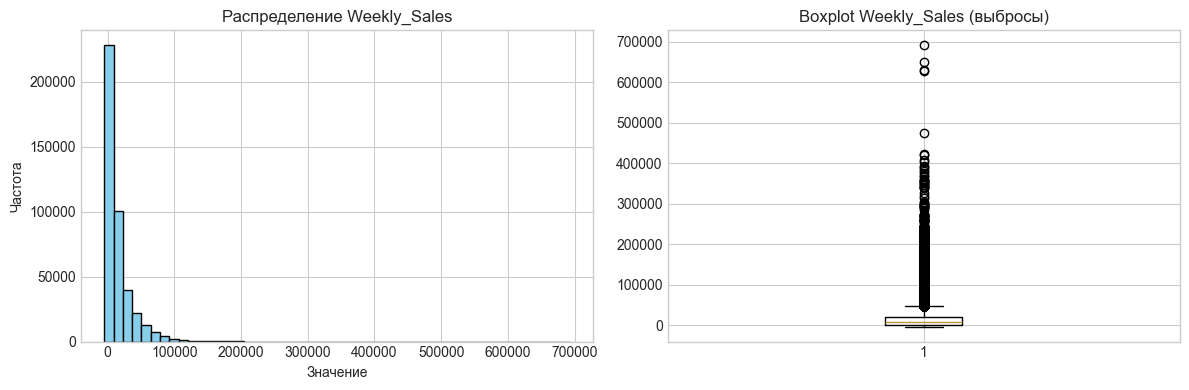

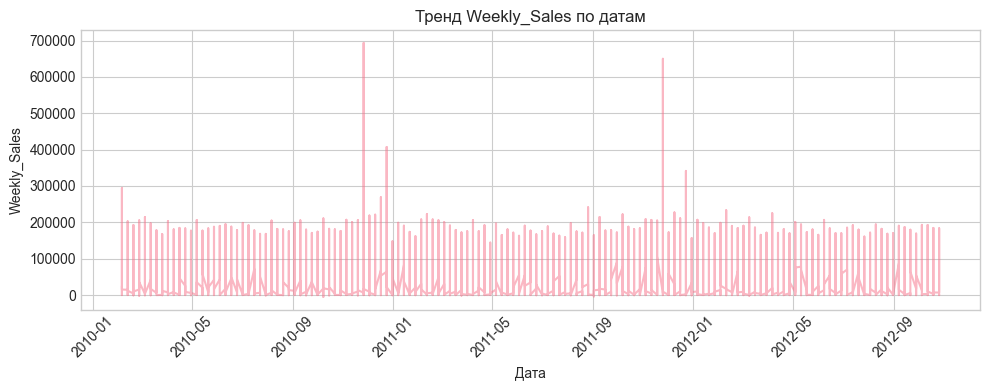

 Дата обработана в формате: день-месяц-год


In [131]:
# Ячейка 5 — Визуализация целевой переменной (ИСПРАВЛЕННАЯ)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # Убираем 3-й график с датами, пока не исправим

# Гистограмма
axes[0].hist(sales_data[target_col], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title(f'Распределение {target_col}')
axes[0].set_xlabel('Значение')
axes[0].set_ylabel('Частота')

# Boxplot
axes[1].boxplot(sales_data[target_col])
axes[1].set_title(f'Boxplot {target_col} (выбросы)')

plt.tight_layout()
plt.show()

# Отдельно обрабатываем даты (если есть)
if 'date' in sales_data.columns or 'Date' in sales_data.columns:
    date_col = 'Date' if 'Date' in sales_data.columns else 'date'
    try:
        # Пробуем разные форматы даты
        sales_data[date_col] = pd.to_datetime(sales_data[date_col], format='%d-%m-%Y', errors='coerce')
        # Если не получилось, пробуем автоопределение
        if sales_data[date_col].isnull().any():
            sales_data[date_col] = pd.to_datetime(sales_data[date_col], dayfirst=True, errors='coerce')
        
        sales_data_sorted = sales_data.sort_values(date_col)
        
        plt.figure(figsize=(10, 4))
        plt.plot(sales_data_sorted[date_col], sales_data_sorted[target_col], alpha=0.5)
        plt.title(f'Тренд {target_col} по датам')
        plt.xlabel('Дата')
        plt.ylabel(target_col)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        print(f" Дата обработана в формате: день-месяц-год")
    except Exception as e:
        print(f" Не удалось обработать дату: {e}")
        print("Продолжаем работу без графика тренда")

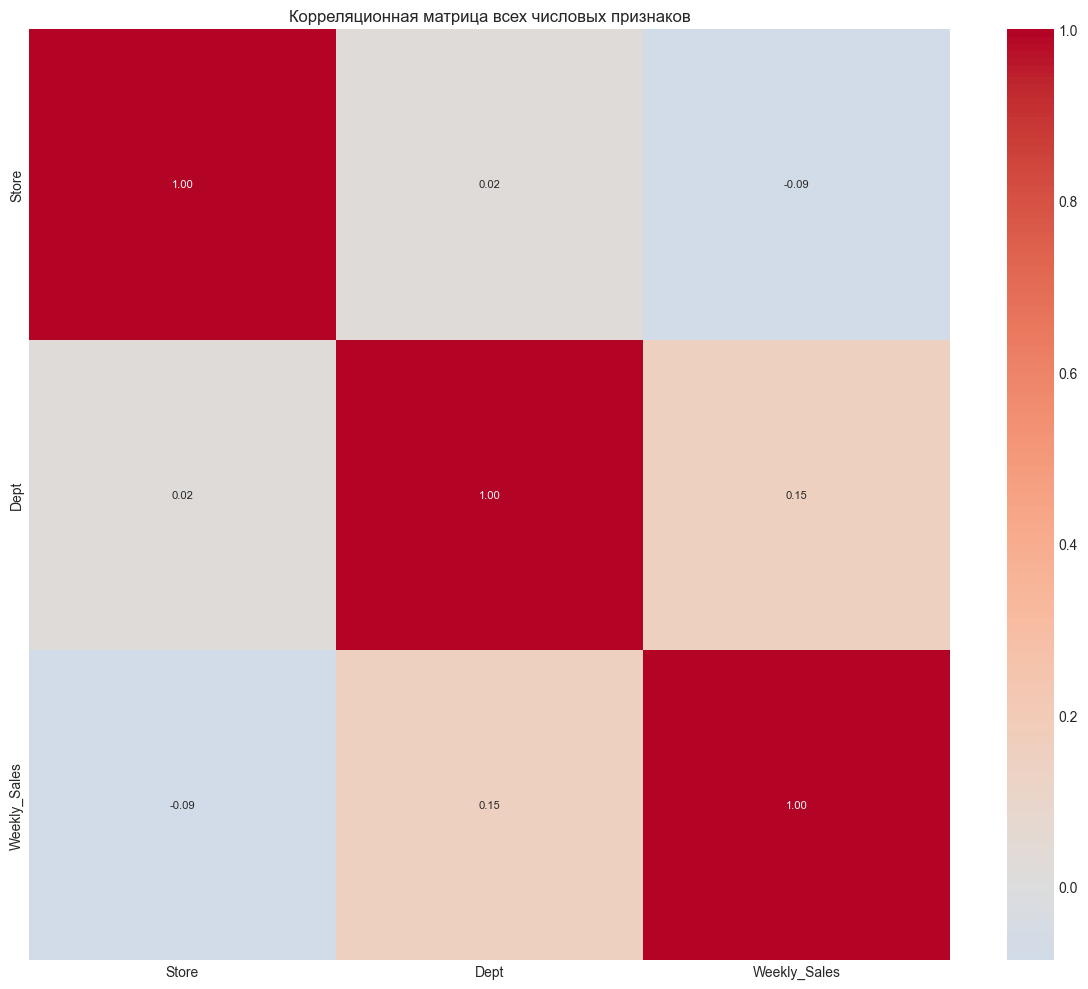


=== КОРРЕЛЯЦИЯ С Weekly_Sales ===
➕ Dept: 0.148
➖ Store: -0.085


In [132]:
# Выбираем только числовые колонки
numeric_cols = sales_data.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 1:
    corr_matrix = sales_data[numeric_cols].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
                annot_kws={'size': 8})
    plt.title('Корреляционная матрица всех числовых признаков')
    plt.tight_layout()
    plt.show()
    
    # Корреляция с целевой переменной
    print(f"\n=== КОРРЕЛЯЦИЯ С {target_col} ===")
    correlations = sales_data[numeric_cols].corr()[target_col].sort_values(ascending=False)
    for col, corr in correlations.items():
        if col != target_col:
            sign = "➕" if corr > 0 else "➖"
            print(f"{sign} {col}: {corr:.3f}")
else:
    print("Недостаточно числовых признаков для корреляционного анализа")

In [133]:
print("=== ПРЕДОБРАБОТКА ДАННЫХ ===\n")

# Копируем данные для обработки
df_processed = sales_data.copy()

# 1. Обработка даты
date_cols = [col for col in df_processed.columns if 'date' in col.lower() or 'Date' in col]
for date_col in date_cols:
    try:
        df_processed[date_col] = pd.to_datetime(df_processed[date_col])
        df_processed['year'] = df_processed[date_col].dt.year
        df_processed['month'] = df_processed[date_col].dt.month
        df_processed['day_of_week'] = df_processed[date_col].dt.dayofweek
        df_processed['day_of_month'] = df_processed[date_col].dt.day
        df_processed = df_processed.drop(date_col, axis=1)
        print(f" Обработан признак даты: {date_col}")
    except:
        print(f" Не удалось обработать {date_col}")

# 2. Обработка пропусков
null_counts = df_processed.isnull().sum()
null_cols = null_counts[null_counts > 0]
if len(null_cols) > 0:
    print(f"\nПропуски в столбцах: {null_cols.to_dict()}")
    # Заполняем числовые медианой, категориальные модой
    for col in null_cols.index:
        if df_processed[col].dtype in ['int64', 'float64']:
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())
            print(f"  - {col}: заполнено медианой ({df_processed[col].median():.2f})")
        else:
            df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])
            print(f"  - {col}: заполнено модой")
else:
    print(" Пропусков нет")

# 3. Обработка выбросов (только для целевой переменной)
Q1 = df_processed[target_col].quantile(0.25)
Q3 = df_processed[target_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_before = df_processed[(df_processed[target_col] < lower_bound) | 
                                (df_processed[target_col] > upper_bound)].shape[0]
print(f"\nВыбросов в {target_col} до обработки: {outliers_before} ({outliers_before/len(df_processed)*100:.2f}%)")

# Ограничиваем выбросы (cap)
df_processed[target_col] = df_processed[target_col].clip(lower=lower_bound, upper=upper_bound)
print(f" Выбросы обработаны (ограничение по перцентилям)")

# 4. Кодирование категориальных переменных
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    if col != target_col:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        print(f" Закодирован признак: {col}")

print(f"\n Данные подготовлены! Итоговое количество признаков: {df_processed.shape[1]}")

=== ПРЕДОБРАБОТКА ДАННЫХ ===

 Обработан признак даты: Date
 Пропусков нет

Выбросов в Weekly_Sales до обработки: 35521 (8.43%)
 Выбросы обработаны (ограничение по перцентилям)

 Данные подготовлены! Итоговое количество признаков: 8


In [134]:
# Отделяем целевую переменную от признаков
X = df_processed.drop(target_col, axis=1)
y = df_processed[target_col]

print(f"Признаки (X): {X.shape[1]} столбцов")
print(f"Целевая переменная (y): {len(y)} значений")

# Масштабирование числовых признаков (для линейной регрессии)
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

print(f" Масштабирование выполнено для {len(numeric_features)} числовых признаков")

# Разделение на обучающую (80%) и тестовую (20%) выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nОбучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")
print(f"Количество признаков: {X_train.shape[1]}")

Признаки (X): 7 столбцов
Целевая переменная (y): 421570 значений
 Масштабирование выполнено для 6 числовых признаков

Обучающая выборка: 337256 строк
Тестовая выборка: 84314 строк
Количество признаков: 7


In [135]:
# Создание и обучение модели
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Прогноз
y_pred_lr = lr_model.predict(X_test)

# Метрики
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("="*40)
print("ЛИНЕЙНАЯ РЕГРЕССИЯ")
print("="*40)
print(f"MAE (средняя абсолютная ошибка): {mae_lr:.2f}")
print(f"MSE (среднеквадратичная ошибка): {mse_lr:.2f}")
print(f"RMSE (корень из MSE): {rmse_lr:.2f}")
print(f"R² (коэффициент детерминации): {r2_lr:.4f}")

if r2_lr < 0:
    print(" R² отрицательный — модель хуже, чем просто среднее значение")
elif r2_lr < 0.5:
    print(" Качество модели: низкое")
elif r2_lr < 0.7:
    print(" Качество модели: среднее")
else:
    print(" Качество модели: высокое")

ЛИНЕЙНАЯ РЕГРЕССИЯ
MAE (средняя абсолютная ошибка): 11947.74
MSE (среднеквадратичная ошибка): 217828792.79
RMSE (корень из MSE): 14759.02
R² (коэффициент детерминации): 0.0173
 Качество модели: низкое


In [136]:
# Создание и обучение модели
dt_model = DecisionTreeRegressor(max_depth=10, min_samples_split=20, random_state=42)
dt_model.fit(X_train, y_train)

# Прогноз
y_pred_dt = dt_model.predict(X_test)

# Метрики
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("="*40)
print("ДЕРЕВО РЕШЕНИЙ")
print("="*40)
print(f"MAE: {mae_dt:.2f}")
print(f"MSE: {mse_dt:.2f}")
print(f"RMSE: {rmse_dt:.2f}")
print(f"R²: {r2_dt:.4f}")

ДЕРЕВО РЕШЕНИЙ
MAE: 4496.96
MSE: 50257691.50
RMSE: 7089.27
R²: 0.7733


In [137]:
# Создание и обучение модели
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_split=10, 
                                  random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Прогноз
y_pred_rf = rf_model.predict(X_test)

# Метрики
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("="*40)
print("СЛУЧАЙНЫЙ ЛЕС")
print("="*40)
print(f"MAE: {mae_rf:.2f}")
print(f"MSE: {mse_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²: {r2_rf:.4f}")

СЛУЧАЙНЫЙ ЛЕС
MAE: 1855.64
MSE: 12134280.34
RMSE: 3483.43
R²: 0.9453


СРАВНЕНИЕ МОДЕЛЕЙ
            Модель          MAE         RMSE       R²
Линейная регрессия 11947.740393 14759.024114 0.017300
    Дерево решений  4496.958309  7089.265935 0.773270
     Случайный лес  1855.637694  3483.429393 0.945258

 ЛУЧШАЯ МОДЕЛЬ: Случайный лес
   R² = 0.9453


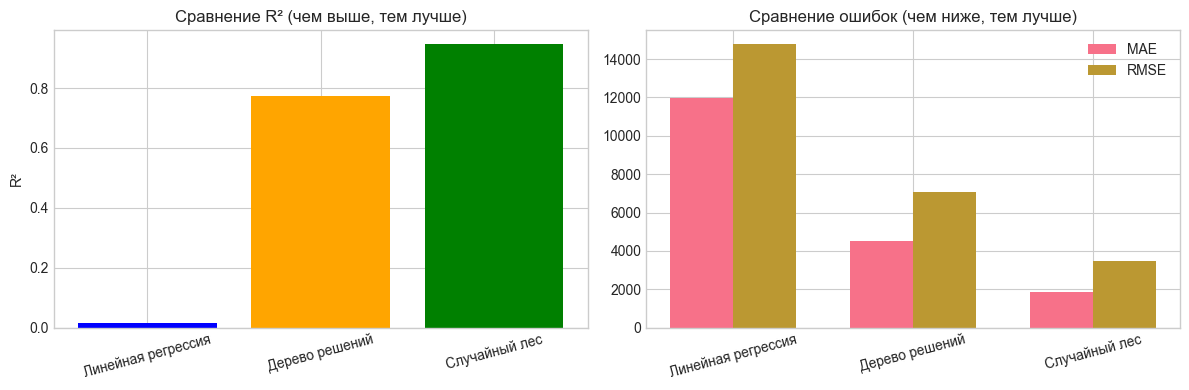

In [138]:
# Таблица сравнения
results = pd.DataFrame({
    'Модель': ['Линейная регрессия', 'Дерево решений', 'Случайный лес'],
    'MAE': [mae_lr, mae_dt, mae_rf],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf],
    'R²': [r2_lr, r2_dt, r2_rf]
})

print("="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*50)
print(results.to_string(index=False))

# Определяем лучшую модель по R²
best_model_name = results.loc[results['R²'].idxmax(), 'Модель']
best_r2 = results['R²'].max()

print(f"\n ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"   R² = {best_r2:.4f}")

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Сравнение R²
axes[0].bar(results['Модель'], results['R²'], color=['blue', 'orange', 'green'])
axes[0].set_title('Сравнение R² (чем выше, тем лучше)')
axes[0].set_ylabel('R²')
axes[0].tick_params(axis='x', rotation=15)

# Сравнение ошибок
x = np.arange(len(results['Модель']))
width = 0.35
axes[1].bar(x - width/2, results['MAE'], width, label='MAE')
axes[1].bar(x + width/2, results['RMSE'], width, label='RMSE')
axes[1].set_title('Сравнение ошибок (чем ниже, тем лучше)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results['Модель'], rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()

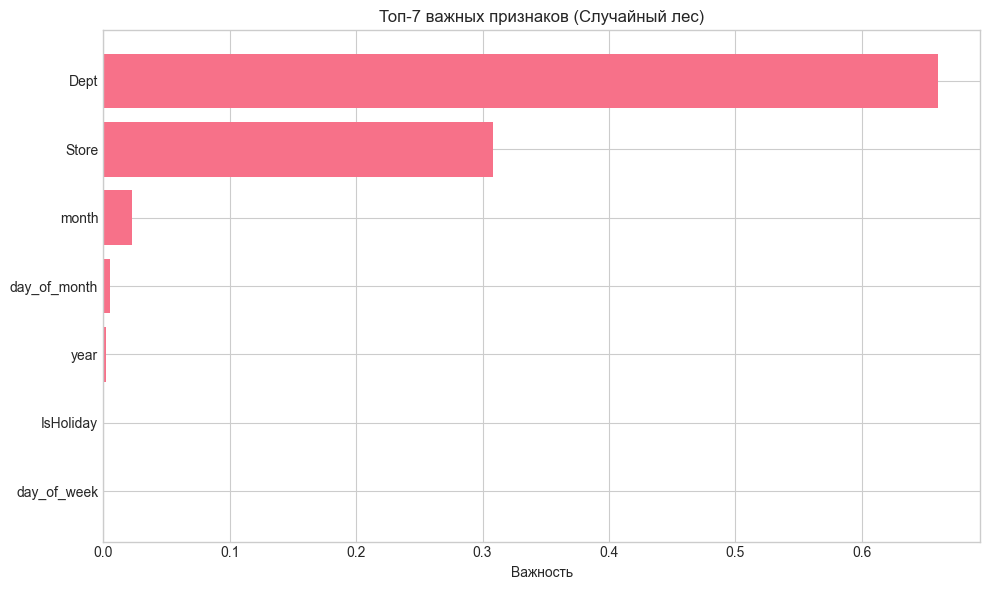


=== ТОП-7 ВАЖНЫХ ПРИЗНАКОВ ===
1. Dept: 0.6605
2. Store: 0.3087
3. month: 0.0228
4. day_of_month: 0.0053
5. year: 0.0020
6. IsHoliday: 0.0008
7. day_of_week: 0.0000


In [139]:
# Используем лучшую модель (Случайный лес или Дерево решений)
if best_model_name == 'Случайный лес':
    best_model = rf_model
elif best_model_name == 'Дерево решений':
    best_model = dt_model
else:
    best_model = lr_model

# Получаем важность признаков
if hasattr(best_model, 'feature_importances_'):
    feature_importance = best_model.feature_importances_
    feature_names = X.columns
    
    # Сортировка по убыванию
    sorted_idx = np.argsort(feature_importance)[::-1]
    
    # Показываем топ-10
    top_n = min(10, len(feature_names))
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(top_n), feature_importance[sorted_idx[:top_n]][::-1])
    plt.yticks(range(top_n), [feature_names[i] for i in sorted_idx[:top_n]][::-1])
    plt.title(f'Топ-{top_n} важных признаков ({best_model_name})')
    plt.xlabel('Важность')
    plt.tight_layout()
    plt.show()
    
    print(f"\n=== ТОП-{top_n} ВАЖНЫХ ПРИЗНАКОВ ===")
    for i in range(top_n):
        print(f"{i+1}. {feature_names[sorted_idx[i]]}: {feature_importance[sorted_idx[i]]:.4f}")
        
elif hasattr(best_model, 'coef_'):
    # Для линейной регрессии
    coefficients = best_model.coef_
    feature_names = X.columns
    
    sorted_idx = np.argsort(np.abs(coefficients))[::-1]
    top_n = min(10, len(feature_names))
    
    plt.figure(figsize=(10, 6))
    colors = ['red' if c < 0 else 'green' for c in coefficients[sorted_idx[:top_n]]]
    plt.barh(range(top_n), coefficients[sorted_idx[:top_n]][::-1], color=colors[::-1])
    plt.yticks(range(top_n), [feature_names[i] for i in sorted_idx[:top_n]][::-1])
    plt.title(f'Топ-{top_n} коэффициентов ({best_model_name})')
    plt.xlabel('Коэффициент (зеленый ➕, красный ➖)')
    plt.tight_layout()
    plt.show()
    
    print(f"\n=== ТОП-{top_n} ВАЖНЫХ ПРИЗНАКОВ ===")
    for i in range(top_n):
        sign = "➕" if coefficients[sorted_idx[i]] > 0 else "➖"
        print(f"{i+1}. {feature_names[sorted_idx[i]]}: {coefficients[sorted_idx[i]]:.4f} {sign}")

In [140]:
# Сохраняем лучшую модель
import joblib

model_filename = f'best_model_{best_model_name.replace(" ", "_").lower()}.pkl'
joblib.dump(best_model, model_filename)
print(f" Модель сохранена в файл: {model_filename}")

# Сохраняем метрики в CSV
results.to_csv('model_comparison_results.csv', index=False)
print(f" Результаты сохранены в: model_comparison_results.csv")

print("\n" + "="*50)
print("ЛАБОРАТОРНАЯ РАБОТА ВЫПОЛНЕНА")
print("="*50)

 Модель сохранена в файл: best_model_случайный_лес.pkl
 Результаты сохранены в: model_comparison_results.csv

ЛАБОРАТОРНАЯ РАБОТА ВЫПОЛНЕНА
